# BOA + CodeCarbon — a teaching walkthrough

**BOA Constrictor** is a *lossless* neural compressor. A small Mamba network predicts the
probability of the **next byte** given the bytes seen so far, and a **range coder** turns those
probabilities into a bitstream of length `-Σ log₂ p(byte)`. Better predictions → fewer bits.
Decompression replays the *same* predictions, so the result is bit-for-bit identical to the input.

**CodeCarbon** measures how much energy (and CO₂) each stage of that pipeline costs.

### What this notebook does, in order

| Step | Cell section | Measured by CodeCarbon |
|---|---|---|
| 1 | Load the CMS data | — |
| 2 | Build the byte-prediction model | — |
| 3 | Train it | ✅ `training` |
| 4 | Plot the training / validation loss | — |
| 5 | Run inference (predict the next byte) | — |
| 6 | Compress with BOA | ✅ `compression` |
| 7 | Decompress and verify the round trip | ✅ `decompression` |
| 8 | Show the energy / emissions results | — |

The BOA implementation is **imported from the `boa-constrictor` repo** — nothing is copied into
this notebook. Run the cells top to bottom.

> On Colab: **Runtime → Change runtime type → GPU** first. A CPU-only runtime works but is slow —
> lower `data_mb` and `epochs` in the config cell.

## Setup

Two cells: install the dependencies, then tell Python where the BOA repo lives.

In [7]:
import subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

def pip(*args):
    print("pip install", *args)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

if IN_COLAB:
    # PyTorch build that matches Colab's CUDA, then the fused Mamba kernels.
    pip("torch==2.8.0", "--index-url", "https://download.pytorch.org/whl/cu128")
    pip("https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.5.2/"
        "causal_conv1d-1.5.2+cu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl")
    pip("https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/"
        "mamba_ssm-2.3.2.post1+cu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl", "--no-deps")
    # Entropy coder, pure-torch Mamba fallback, energy tracking, plotting.
    # minGRU-pytorch is imported at the top of the repo's model.py, so it is required
    # even when the backbone is Mamba.
    pip("constriction==0.4.1", "mambapy==1.2.0", "minGRU-pytorch", "codecarbon>=3.2,<4",
        "pandas>=2.0", "matplotlib>=3.0", "tqdm", "pybind11")
else:
    print("Local run. Install once with:\n"
          "  pip install torch constriction==0.4.1 mambapy==1.2.0 minGRU-pytorch \\\n"
          "              codecarbon pandas matplotlib tqdm")

pip install torch==2.8.0 --index-url https://download.pytorch.org/whl/cu128
pip install https://github.com/Dao-AILab/causal-conv1d/releases/download/v1.5.2/causal_conv1d-1.5.2+cu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl
pip install https://github.com/state-spaces/mamba/releases/download/v2.3.2.post1/mamba_ssm-2.3.2.post1+cu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl --no-deps
pip install constriction==0.4.1 mambapy==1.2.0 minGRU-pytorch codecarbon>=3.2,<4 pandas>=2.0 matplotlib>=3.0 tqdm pybind11


In [8]:
import sys
from pathlib import Path

# --- 1. Find the BOA repo (a folder containing boa.py and model.py) and import from it -------
def find_boa_repo(start: Path):
    for folder in [start, *start.parents]:
        for candidate in (folder / "boa-constrictor-main", folder / "boa-constrictor", folder):
            if (candidate / "boa.py").exists() and (candidate / "model.py").exists():
                return candidate
    return None

BOA_REPO = find_boa_repo(Path.cwd())

if BOA_REPO is None and IN_COLAB:
    subprocess.check_call(["git", "clone", "--depth", "1",
                           "https://github.com/AkkiG2401/boa-constrictor.git",
                           "/content/boa-constrictor"])
    BOA_REPO = Path("/content/boa-constrictor")

if BOA_REPO is None:
    raise FileNotFoundError(
        "Could not find the BOA repo. Put the 'boa-constrictor-main' folder next to this "
        "project, or set BOA_REPO = Path('/path/to/boa-constrictor') by hand.")

sys.path.insert(0, str(BOA_REPO))          # `import boa`, `import model`, ... now work

# --- 2. Where this notebook reads data and writes results ------------------------------------
PROJECT_ROOT = (Path("/content/BOA_carbon_project") if IN_COLAB
                else (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
DATA_DIR, RESULTS_DIR, ARTIFACTS_DIR = (PROJECT_ROOT / n for n in ("data", "results", "artifacts"))
for d in (DATA_DIR, RESULTS_DIR, ARTIFACTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("BOA repo:    ", BOA_REPO)
print("Project root:", PROJECT_ROOT)

BOA repo:     /content/boa-constrictor
Project root: /content/BOA_carbon_project


## Configuration

Everything you might want to change lives here. The defaults are sized for a **quick demo**
(a slice of the file, a few epochs); the published CMS experiment uses the full 47.6 MB file and
40 epochs.

In [9]:
import torch

CONFIG = {
    # ---- data: CMS jets stored as rows of 24 float32 values -------------------
    "data_url":    "https://raw.githubusercontent.com/AkkiG2401/boa-constrictor/main/"
                   "experiments/cms_experiment/CMS_DATA_float32.bin",
    "data_mb":     2.0,      # MB of the 47.6 MB file to use (None = all of it)
    "n_features":  24,

    # ---- model ---------------------------------------------------------------
    "backbone":    "mambav1",  # also: mamba2, transformer, gru, lstm, ...
    "d_model":     64,
    "num_layers":  2,
    "vocab_size":  256,        # one symbol per byte

    # ---- training ------------------------------------------------------------
    "seq_len":     10000,      # bytes per training sequence
    "batch_size":  5,
    "lr":          5e-4,
    "epochs":      3,          # the paper uses 40
    "precision":   "fp32",     # fp32 | fp16 | bf16 (mixed precision is CUDA-only)
    "splits":      (0.8, 0.1, 0.1),

    # ---- compression ---------------------------------------------------------
    "chunk_bytes": 2048,       # the file is coded in independent chunks of this size

    # ---- energy measurement --------------------------------------------------
    "country_iso": "GBR",      # where this machine actually runs (grid carbon intensity)

    "seed":        42,
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(CONFIG["seed"])
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(CONFIG["seed"])

print(f"torch {torch.__version__} on {DEVICE}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else " — no GPU, this will be slow"))

torch 2.8.0+cu128 on cuda (Tesla T4)


## The CodeCarbon measurement helper

One helper for the whole notebook. `with track("training"): ...` starts an offline CodeCarbon
tracker, runs the block, stops the tracker, and stores the numbers in `MEASUREMENTS["training"]`.

Two details that matter for correct numbers:

* **CUDA is synchronised** at both ends of the block, so GPU work that was queued asynchronously
  finishes *inside* the measured window.
* Each stage gets **its own tracker and its own CSV** in `results/`, so training, compression and
  decompression can be compared.

In [10]:
import time
from contextlib import contextmanager

import pandas as pd
from codecarbon import OfflineEmissionsTracker

MEASUREMENTS = {}          # stage name -> runtime / energy / emissions

@contextmanager
def track(stage):
    '''Measure one stage of the pipeline; results land in MEASUREMENTS[stage].'''
    csv_path = RESULTS_DIR / f"codecarbon_{stage}.csv"
    tracker = OfflineEmissionsTracker(
        project_name=f"BOA_{stage}",
        country_iso_code=CONFIG["country_iso"],
        output_dir=str(RESULTS_DIR),
        output_file=csv_path.name,
        measure_power_secs=1,        # compression can be short, so sample often
        tracking_mode="machine",
        log_level="error",
        save_to_api=False,
    )

    if DEVICE == "cuda":
        torch.cuda.synchronize()
    tracker.start()
    start = time.perf_counter()
    try:
        yield
    finally:
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        runtime_s = time.perf_counter() - start
        emissions_kg = tracker.stop()

        row = pd.read_csv(csv_path).iloc[-1] if csv_path.exists() else {}
        get = lambda key: float(row[key]) if key in row else float("nan")
        MEASUREMENTS[stage] = {
            "stage": stage,
            "runtime_s": runtime_s,
            "energy_kWh": get("energy_consumed"),
            "cpu_kWh": get("cpu_energy"),
            "gpu_kWh": get("gpu_energy"),
            "ram_kWh": get("ram_energy"),
            "emissions_kgCO2eq": float(emissions_kg) if emissions_kg else get("emissions"),
        }
        m = MEASUREMENTS[stage]
        print(f"\n[{stage}] {m['runtime_s']:.1f} s | {m['energy_kWh']:.3e} kWh | "
              f"{m['emissions_kgCO2eq']:.3e} kg CO2eq  ->  {csv_path.name}")

## 1 · Load the data

`CMS_DATA_float32.bin` is a flat array of IEEE-754 `float32` values: **N rows × 24 columns**, one
row per reconstructed jet (`pt, eta, phi, mass, jet_area`, per-particle-type energies, …).

BOA compresses **raw bytes**, so all we need is a `bytes` object and a file on disk.

In [11]:
import numpy as np

SOURCE_FILE = DATA_DIR / "CMS_DATA_float32.bin"
if not SOURCE_FILE.exists():
    import urllib.request
    print("Downloading CMS data ...")
    urllib.request.urlretrieve(CONFIG["data_url"], SOURCE_FILE)

# Take a whole number of jets from the front of the file.
full_bytes = SOURCE_FILE.stat().st_size
n_bytes = full_bytes if CONFIG["data_mb"] is None else min(full_bytes, int(CONFIG["data_mb"] * 1e6))
n_bytes -= n_bytes % (4 * CONFIG["n_features"])

data = np.fromfile(SOURCE_FILE, dtype=np.uint8, count=n_bytes).tobytes()

INPUT_PATH = DATA_DIR / "cms_input.bin"     # the exact file we will compress
INPUT_PATH.write_bytes(data)

jets = np.frombuffer(data, dtype=np.float32).reshape(-1, CONFIG["n_features"])
print(f"Whole file:  {full_bytes/1e6:.1f} MB")
print(f"Using:       {len(data)/1e6:.2f} MB = {len(jets):,} jets x {CONFIG['n_features']} features")
print("First jet (pt, eta, phi, mass, area):", np.round(jets[0, :5], 3))

Whole file:  49.9 MB
Using:       2.00 MB = 20,833 jets x 24 features
First jet (pt, eta, phi, mass, area): [97.294 -1.047 -1.379 16.212  0.798]


## 2 · Build the model

`BoaConstrictor(...)` returns a byte predictor: given bytes so far, it outputs a probability for
each of the 256 possible next bytes. On a GPU it uses the fused `mamba_ssm` kernels; if those are
not installed it falls back to the pure-torch `mambapy` implementation of the same architecture.

In [12]:
from model import BoaConstrictor, ByteDataloader, make_splits

shape = dict(d_model=CONFIG["d_model"], num_layers=CONFIG["num_layers"],
             vocab_size=CONFIG["vocab_size"])

try:
    # device="cuda" selects the fused mamba_ssm kernels (CUDA only).
    model = BoaConstrictor(**shape, device=DEVICE, backbone=CONFIG["backbone"])
    PURE_TORCH_MODEL = DEVICE != "cuda"
except Exception as err:
    print(f"Fused mamba_ssm unavailable ({err});\nfalling back to pure-torch mambapy.")
    model = BoaConstrictor(**shape, device="cpu", backbone=CONFIG["backbone"])
    PURE_TORCH_MODEL = True

model = model.to(DEVICE)
print(f"\n{CONFIG['backbone']} byte predictor on {DEVICE} — "
      f"{sum(p.numel() for p in model.parameters()):,} parameters")


mambav1 byte predictor on cuda — 169,152 parameters


## 3 · Train the model  🔋

Split the bytes into train / validation / test, then minimise the cross-entropy between the
predicted next-byte distribution and the true next byte. The loop reports **bits per byte (bpp)** —
the expected code length per input byte, so `8 / bpp` is the compression ratio the model implies.

`train(...)` is the repo's own training loop (`train.py`). It optionally logs metrics to a
Weights & Biases run; we hand it a tiny stand-in object instead, purely so we can plot the curves
in the next cell — no account or extra dependency needed.

**The whole `train(...)` call sits inside the CodeCarbon block**, so the measurement covers the
epoch loop, validation, the final test evaluation and checkpoint writing.

In [13]:
from train import train

train_bytes, val_bytes, test_bytes = make_splits(
    data, CONFIG["seq_len"], CONFIG["batch_size"], splits=tuple(CONFIG["splits"]))

loader = lambda b: ByteDataloader(b, seq_len=CONFIG["seq_len"],
                                  batch_size=CONFIG["batch_size"], device=DEVICE)
train_loader, val_loader, test_loader = loader(train_bytes), loader(val_bytes), loader(test_bytes)
print(f"train/val/test bytes: {len(train_bytes):,} / {len(val_bytes):,} / {len(test_bytes):,}"
      f"  ({len(train_loader)} batches per epoch)")

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=0.01)
criterion = torch.nn.CrossEntropyLoss()


class LossRecorder:
    '''Stand-in for a wandb run: just remembers the losses train() reports.'''
    def __init__(self):
        self.epochs, self.train_bpp, self.val_bpp, self.summary = [], [], [], {}
        self._epoch_batches = []

    def log(self, metrics, step=None):
        if "train/bpp" in metrics:                       # once per batch
            self._epoch_batches.append(metrics["train/bpp"])
        if "val/bpp" in metrics:                         # once per epoch
            self.epochs.append(metrics["epoch"])
            self.train_bpp.append(sum(self._epoch_batches) / max(len(self._epoch_batches), 1))
            self.val_bpp.append(metrics["val/bpp"])
            self._epoch_batches = []


history = LossRecorder()

with track("training"):
    train(
        model, train_loader, val_loader, test_loader, optimizer, criterion,
        device=DEVICE,
        name="cms_experiment",
        NUM_EPOCHS=CONFIG["epochs"],
        PRECISION=CONFIG["precision"],
        vocab_size=CONFIG["vocab_size"],
        progress=True,
        wandb_run=history,
    )

# train() writes the final weights next to the notebook; keep a copy with the results.
import shutil
MODEL_PATH = ARTIFACTS_DIR / f"cms_experiment_final_model_{CONFIG['precision']}.pt"
shutil.copy2(Path(f"cms_experiment_final_model_{CONFIG['precision']}.pt"), MODEL_PATH)
print("Model saved to:", MODEL_PATH)

[codecarbon INFO @ 00:55:39] offline tracker init
[codecarbon WARNING @ 00:55:39] Multiple instances of codecarbon are allowed to run at the same time.


train/val/test bytes: 1,550,000 / 150,000 / 250,000  (31 batches per epoch)
[INFO] Using precision = fp32


Epoch 1 [fp32]:   0%|          | 0/31 [00:00<?, ?it/s]

  Epoch 1 throughput: 635,833 tok/s (0.61 MB/s), 2.4s
[Epoch 1] val bpp=3.8274 (ratio ~ 2.09x)  lr=5.00e-04


Epoch 2 [fp32]:   0%|          | 0/31 [00:00<?, ?it/s]

  Epoch 2 throughput: 924,534 tok/s (0.88 MB/s), 1.7s
[Epoch 2] val bpp=3.4699 (ratio ~ 2.31x)  lr=5.00e-04


Epoch 3 [fp32]:   0%|          | 0/31 [00:00<?, ?it/s]

  Epoch 3 throughput: 923,607 tok/s (0.88 MB/s), 1.7s
[Epoch 3] val bpp=3.2017 (ratio ~ 2.50x)  lr=5.00e-04
[TEST] bpp=3.1955  ratio ~ 2.50x

[training] 6.0 s | 1.258e-04 kWh | 2.990e-05 kg CO2eq  ->  codecarbon_training.csv
Model saved to: /content/BOA_carbon_project/artifacts/cms_experiment_final_model_fp32.pt


## 4 · Plot the loss *(optional)*

Loss is in bits per byte, so the right-hand reading of the same curve is "how many times smaller
the file gets": `8 / bpp`. A validation curve that stops falling means more epochs will not buy
more compression.

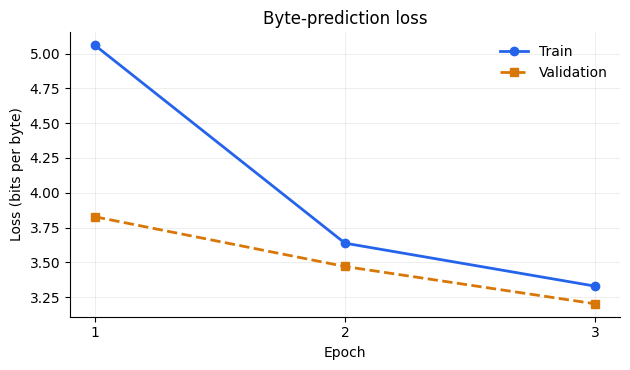

Final validation loss: 3.202 bits/byte -> implied compression ratio 2.50x


In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(history.epochs, history.train_bpp, color="#2563eb", lw=2, marker="o", ms=6, label="Train")
ax.plot(history.epochs, history.val_bpp, color="#d97706", lw=2, ls="--", marker="s", ms=6,
        label="Validation")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (bits per byte)")
ax.set_title("Byte-prediction loss")
ax.set_xticks(history.epochs)
ax.grid(alpha=0.25, lw=0.6)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print(f"Final validation loss: {history.val_bpp[-1]:.3f} bits/byte "
      f"-> implied compression ratio {8 / history.val_bpp[-1]:.2f}x")

## 5 · Run inference

This is the only thing the compressor asks the model to do: **given the bytes so far, how likely is
each possible next byte?** Compression feeds those probabilities to a range coder; decompression
asks the same question again and gets the same answer, which is why the round trip is exact.

In [15]:
sample = torch.tensor(list(data[:4096]), dtype=torch.long, device=DEVICE).unsqueeze(0)

model.eval()
with torch.no_grad():
    logits = model(sample[:, :-1])                       # [1, L-1, 256] one distribution per position

# Probabilities for the byte that follows the sample's last-but-one byte.
probs = torch.softmax(logits[0, -1].float(), dim=-1)
top_p, top_bytes = probs.topk(5)

print("Most likely next byte values:")
for byte_value, p in zip(top_bytes.tolist(), top_p.tolist()):
    print(f"  0x{byte_value:02x} ({byte_value:3d})  p = {p:6.2%}  ->  {-np.log2(max(p, 1e-12)):.2f} bits")
print(f"  (the true next byte is 0x{sample[0, -1].item():02x})")

nll = torch.nn.functional.cross_entropy(logits.reshape(-1, CONFIG["vocab_size"]),
                                        sample[0, 1:].reshape(-1))
bpp = nll.item() / np.log(2)
print(f"\nOver these {sample.shape[1]:,} bytes: {bpp:.3f} bits/byte -> ~{8 / bpp:.2f}x compression")

Most likely next byte values:
  0x00 (  0)  p = 91.15%  ->  0.13 bits
  0x40 ( 64)  p =  1.70%  ->  5.88 bits
  0x41 ( 65)  p =  1.00%  ->  6.64 bits
  0x80 (128)  p =  0.96%  ->  6.71 bits
  0xc0 (192)  p =  0.40%  ->  7.96 bits
  (the true next byte is 0x00)

Over these 4,096 bytes: 3.384 bits/byte -> ~2.36x compression


## 6 · Compress with BOA  🔋

`BOA(codec_device, output_path, model)` returns an object with two methods — `compress()` and
`decompress()`. The file is coded in independent chunks of `chunk_bytes`, which is what lets the
GPU run many streams in parallel.

The entropy coder is chosen here: a custom CUDA range coder on GPU (compiled on first import —
deliberately done *before* the tracker starts, so the one-off build cost is not charged to
compression), otherwise `constriction` on CPU.

> ### Using a different compression algorithm
> The rest of the notebook only needs two things from this step and the next:
> **`BOA_PATH`** (the compressed file) and **`restored`** (the bytes you get back).
> Swap the two calls below for any other codec and everything downstream still works —
> there is a worked LZMA example at the end of the notebook.

In [16]:
import types

# --- choose the entropy coder (and build the CUDA extension now, not inside the measurement) ---
CODEC_DEVICE = "cpu"
if DEVICE == "cuda":
    try:
        import gpu_range_coder                    # first import compiles a CUDA extension
        CODEC_DEVICE = "cuda"
        print("[codec] GPU range coder ready")
    except Exception as err:
        print(f"[codec] GPU range coder unavailable ({err});\n        using the constriction CPU coder")
        # codec.py imports gpu_range_coder whenever a GPU is visible; a placeholder lets the
        # CPU coder be imported anyway.
        sys.modules["gpu_range_coder"] = types.ModuleType("gpu_range_coder")

if CODEC_DEVICE == "cpu" and not PURE_TORCH_MODEL:
    raise RuntimeError("The CPU coder cannot run a fused mamba_ssm model. Re-run the model cell "
                       "after uninstalling mamba_ssm, or make nvcc available.")

from boa import BOA

BOA_PATH = ARTIFACTS_DIR / "cms_experiment.boa"
BOA_PATH.unlink(missing_ok=True)
boa = BOA(CODEC_DEVICE, str(BOA_PATH), model)

with track("compression"):
    boa.compress(data_path=str(INPUT_PATH), seq_size=CONFIG["chunk_bytes"], progress=True)

compressed_bytes = BOA_PATH.stat().st_size
model_bytes = MODEL_PATH.stat().st_size
print(f"\nOriginal:   {len(data):,} bytes")
print(f"Compressed: {compressed_bytes:,} bytes")
print(f"Ratio: {len(data)/compressed_bytes:.3f}x   ({8*compressed_bytes/len(data):.3f} bits/byte)")
print(f"Ratio including the {model_bytes/1e6:.2f} MB model: "
      f"{len(data)/(compressed_bytes + model_bytes):.3f}x")

[codec] GPU range coder ready
[compress] gpu_streams=977 (chunk_len=2048, free=13.6GiB)
256


/content/boa-constrictor/boa.py:279: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  t = torch.from_numpy(np.ascontiguousarray(sl)).unsqueeze(0)


Compress (GPU streams x977):   0%|          | 0.0/1952.1396484375 [00:00<?, ?KB/s]

Compression complete: 977 chunks, chunk_len=2048, last=1120

[compression] 7.4 s | 9.441e-05 kWh | 2.243e-05 kg CO2eq  ->  codecarbon_compression.csv

Original:   1,999,968 bytes
Compressed: 803,892 bytes
Ratio: 2.488x   (3.216 bits/byte)
Ratio including the 0.69 MB model: 1.338x


## 7 · Decompress and verify  🔋

Decompression re-runs the model byte by byte to invert the range coder — that is why it costs
roughly as much energy as compression. The SHA-256 check sits *outside* the measured block,
because verifying the experiment is not part of decompression.

In [17]:
import hashlib

with track("decompression"):
    restored = boa.decompress(progress=True)

lossless = restored == data
print(f"\nOriginal     SHA-256: {hashlib.sha256(data).hexdigest()}")
print(f"Decompressed SHA-256: {hashlib.sha256(restored).hexdigest()}")
print("LOSSLESS round trip confirmed" if lossless else "MISMATCH — the round trip failed")
assert lossless

recovered = np.frombuffer(restored, dtype=np.float32).reshape(-1, CONFIG["n_features"])
print(f"Recovered {len(recovered):,} jets — largest difference from the original: "
      f"{np.max(np.abs(jets - recovered))}")

Total compressed size from disk: 800904 bytes
[decompress] gpu_streams=977 (free=13.5GiB)


Decompress (GPU streams x977):   0%|          | 0.0/1952.1396484375 [00:00<?, ?KB/s]


[decompression] 5.4 s | 7.092e-05 kWh | 1.685e-05 kg CO2eq  ->  codecarbon_decompression.csv

Original     SHA-256: e72ba3e911da1f022ea4eeb2d4c98f17535e7f2fa3d6fe274e6b892b9237b978
Decompressed SHA-256: e72ba3e911da1f022ea4eeb2d4c98f17535e7f2fa3d6fe274e6b892b9237b978
LOSSLESS round trip confirmed
Recovered 20,833 jets — largest difference from the original: 0.0


## 8 · Energy and emissions results

The three trackers, side by side. `energy_kWh` is what the machine drew during that stage;
`emissions_kgCO2eq` converts it with the carbon intensity of the `country_iso` grid.

Training is a **one-off** cost paid per dataset; compression is paid once per file; decompression
is paid **every time somebody reads the data back** — which is what makes the last row the
interesting one when comparing compressors.

In [18]:
summary = pd.DataFrame([MEASUREMENTS[s] for s in ("training", "compression", "decompression")])
summary["kWh_per_GB"] = summary["energy_kWh"] / (len(data) / 1e9)   # energy per GB of input data

pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
display(summary.set_index("stage"))

summary.to_csv(RESULTS_DIR / "cleanup_run_summary.csv", index=False)
print("Saved:", RESULTS_DIR / "cleanup_run_summary.csv")

print(f"\nInput {len(data)/1e6:.2f} MB -> {compressed_bytes/1e6:.2f} MB "
      f"({len(data)/compressed_bytes:.2f}x, lossless)")
print(f"Compression   {len(data)/1e6/MEASUREMENTS['compression']['runtime_s']:.2f} MB/s")
print(f"Decompression {len(data)/1e6/MEASUREMENTS['decompression']['runtime_s']:.2f} MB/s")
print(f"Total measured energy: {summary['energy_kWh'].sum():.3e} kWh "
      f"({summary['emissions_kgCO2eq'].sum():.3e} kg CO2eq)")

,runtime_s,energy_kWh,cpu_kWh,gpu_kWh,ram_kWh,emissions_kgCO2eq,kWh_per_GB
stage,,,,,,,
training,6.02252,0.000125842,4.25586e-06,0.000104845,1.67421e-05,2.98988e-05,0.0629223
compression,7.4329,9.44145e-05,7.86945e-06,6.59728e-05,2.05722e-05,2.24318e-05,0.047208
decompression,5.39707,7.09216e-05,5.03677e-06,5.09517e-05,1.49332e-05,1.68502e-05,0.0354614


Saved: /content/BOA_carbon_project/results/cleanup_run_summary.csv

Input 2.00 MB -> 0.80 MB (2.49x, lossless)
Compression   0.27 MB/s
Decompression 0.37 MB/s
Total measured energy: 2.912e-04 kWh (6.918e-05 kg CO2eq)


## 9 · Swapping BOA for another compressor *(optional)*

The measurement harness knows nothing about BOA. Any codec that can write a compressed file and
give the bytes back fits in the same two blocks — here is LZMA, measured exactly the same way, as
a baseline to compare against the numbers above.

In [19]:
import lzma

LZMA_PATH = ARTIFACTS_DIR / "cms_input.xz"

with track("lzma_compression"):
    LZMA_PATH.write_bytes(lzma.compress(data, preset=6))

with track("lzma_decompression"):
    restored_lzma = lzma.decompress(LZMA_PATH.read_bytes())

assert restored_lzma == data
print(f"\nLZMA ratio: {len(data)/LZMA_PATH.stat().st_size:.3f}x   "
      f"(BOA: {len(data)/compressed_bytes:.3f}x)")

display(pd.DataFrame([MEASUREMENTS[s] for s in
                      ("compression", "decompression", "lzma_compression", "lzma_decompression")]
                     ).set_index("stage"))


[lzma_compression] 1.0 s | 1.204e-05 kWh | 2.860e-06 kg CO2eq  ->  codecarbon_lzma_compression.csv

[lzma_decompression] 0.1 s | 1.848e-07 kWh | 4.390e-08 kg CO2eq  ->  codecarbon_lzma_decompression.csv

LZMA ratio: 3.163x   (BOA: 2.488x)


,runtime_s,energy_kWh,cpu_kWh,gpu_kWh,ram_kWh,emissions_kgCO2eq
stage,,,,,,
compression,7.4329,9.44145e-05,7.86945e-06,6.59728e-05,2.05722e-05,2.24318e-05
decompression,5.39707,7.09216e-05,5.03677e-06,5.09517e-05,1.49332e-05,1.68502e-05
lzma_compression,1.04401,1.2038e-05,1.38021e-06,7.87112e-06,2.78668e-06,2.8601e-06
lzma_decompression,0.0516527,1.84792e-07,3.19975e-08,0,1.52794e-07,4.39045e-08


### Where to go next

* Raise `data_mb` and `epochs` in the config cell and watch both the compression ratio and the
  training energy grow — the trade-off at the heart of neural compression.
* Try another `backbone` (`transformer`, `gru`, `lstm`) — the rest of the notebook is unchanged.
* Compare `kWh_per_GB` for BOA against LZMA/ZSTD, and against the energy of simply *storing* the
  uncompressed data, to see when the neural codec actually pays for itself.